COVID-19 Data Analysis and Visualization

1.import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

Cell 2 — load dataset

In [2]:
df = pd.read_csv("covid_19.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())

Dataset loaded successfully!
Rows: 238
Columns: 9


,country,continent,population,day,time,Cases,Recovered,Deaths,Tests
0,Saint-Helena,Africa,6115.0,2024-06-30,2024-06-30T16:15:16+00:00,2166,2.0,NaN,NaN
1,Falkland-Islands,South-America,3539.0,2024-06-30,2024-06-30T16:15:16+00:00,1930,1930.0,NaN,8632.0
2,Montserrat,North-America,4965.0,2024-06-30,2024-06-30T16:15:16+00:00,1403,1376.0,8.0,17762.0
3,Diamond-Princess,NaN,NaN,2024-06-30,2024-06-30T16:15:16+00:00,712,699.0,13.0,NaN
4,Vatican-City,Europe,799.0,2024-06-30,2024-06-30T16:15:16+00:00,29,29.0,NaN,NaN


Cell 3 — Dataset Information

In [4]:
print("Column Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
display(df.isnull().sum().to_frame("Missing Values"))

print("\nDataset Summary:")
display(df.describe(include="all").T)

Column Names:
['country', 'continent', 'population', 'day', 'time', 'Cases', 'Recovered', 'Deaths', 'Tests']

Data Types:
country           str
continent         str
population    float64
day               str
time              str
Cases           int64
Recovered     float64
Deaths        float64
Tests         float64
dtype: object

Missing Values:


,Missing Values
country,0
continent,2
population,9
day,0
time,0
Cases,0
Recovered,48
Deaths,5
Tests,25



Dataset Summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,238,238,Saint-Helena,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
continent,236,7,Africa,59,NaN,NaN,NaN,NaN,NaN,NaN,NaN
population,229.0,NaN,NaN,NaN,34694039.873362,138637445.812325,799.0,445431.0,5797805.0,22102838.0,1448471400.0
day,238,1,2024-06-30,238,NaN,NaN,NaN,NaN,NaN,NaN,NaN
time,238,7,2024-06-30T16:15:12+00:00,47,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cases,238.0,NaN,NaN,NaN,8883449.365546,51930306.077514,9.0,27418.75,232042.5,1565481.25,704753890.0
Recovered,190.0,NaN,NaN,NaN,10062139.905263,55555193.428142,2.0,21972.5,235145.5,2078211.5,675619811.0
Deaths,233.0,NaN,NaN,NaN,90266.214592,516343.391297,1.0,225.0,2570.0,18057.0,7010681.0
Tests,213.0,NaN,NaN,NaN,32988287.85446,119877917.250034,7850.0,347815.0,2226216.0,13463733.0,1186851502.0


Cell 4 — Data Cleaning

In [5]:
data = df.copy()

# Convert date
data["day"] = pd.to_datetime(data["day"], errors="coerce")

# Convert time
data["time"] = pd.to_datetime(
    data["time"],
    errors="coerce",
    utc=True
)

# Convert numeric columns
numeric_cols = [
    "population",
    "Cases",
    "Recovered",
    "Deaths",
    "Tests"
]

for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors="coerce")

# Fill missing numerical values
for col in ["Recovered", "Deaths", "Tests"]:
    data[col] = data[col].fillna(0)

# Remove aggregate/summary rows
summary_rows = [
    "All",
    "Africa",
    "Asia",
    "Europe",
    "North-America",
    "South-America",
    "Oceania"
]

country_data = data[
    ~data["country"].isin(summary_rows)
].copy()

# Keep records having continent information
continent_data = country_data[
    country_data["continent"].notna()
].copy()

print("Data cleaning completed successfully!")
print("Country records:", len(country_data))

Data cleaning completed successfully!
Country records: 231


5 — Create New Metrics

In [6]:
# Recovery Rate
country_data["Recovery Rate (%)"] = np.where(
    country_data["Cases"] > 0,
    country_data["Recovered"] / country_data["Cases"] * 100,
    0
)

# Death Rate
country_data["Death Rate (%)"] = np.where(
    country_data["Cases"] > 0,
    country_data["Deaths"] / country_data["Cases"] * 100,
    0
)

# Cases per 100,000 population
country_data["Cases per 100K Population"] = np.where(
    country_data["population"] > 0,
    country_data["Cases"] / country_data["population"] * 100000,
    np.nan
)

display(
    country_data[
        [
            "country",
            "Cases",
            "Recovered",
            "Deaths",
            "Recovery Rate (%)",
            "Death Rate (%)",
            "Cases per 100K Population"
        ]
    ].head(10)
)

,country,Cases,Recovered,Deaths,Recovery Rate (%),Death Rate (%),Cases per 100K Population
0,Saint-Helena,2166,2.0,0.0,0.092336,0.000000,35421.095666
1,Falkland-Islands,1930,1930.0,0.0,100.000000,0.000000,54535.179429
2,Montserrat,1403,1376.0,8.0,98.075552,0.570207,28257.804632
3,Diamond-Princess,712,699.0,13.0,98.174157,1.825843,NaN
4,Vatican-City,29,29.0,0.0,100.000000,0.000000,3629.536921
5,Western-Sahara,10,9.0,1.0,90.000000,10.000000,1.597033
6,MS-Zaandam,9,7.0,2.0,77.777778,22.222222,NaN
7,China,503302,379053.0,5272.0,75.313231,1.047482,34.747113
8,Tokelau,80,0.0,0.0,0.000000,0.000000,5805.515239
9,Saint-Pierre-Miquelon,3452,2449.0,2.0,70.944380,0.057937,59940.961973


6 — Overall COVID Statistics

In [7]:
total_cases = country_data["Cases"].sum()
total_recovered = country_data["Recovered"].sum()
total_deaths = country_data["Deaths"].sum()
total_tests = country_data["Tests"].sum()

overall_recovery_rate = (
    total_recovered / total_cases * 100
    if total_cases > 0 else 0
)

overall_death_rate = (
    total_deaths / total_cases * 100
    if total_cases > 0 else 0
)

print("COVID-19 OVERALL STATISTICS")
print("=" * 40)

print(f"Total Cases       : {total_cases:,.0f}")
print(f"Total Recovered   : {total_recovered:,.0f}")
print(f"Total Deaths      : {total_deaths:,.0f}")
print(f"Total Tests       : {total_tests:,.0f}")
print(f"Recovery Rate     : {overall_recovery_rate:.2f}%")
print(f"Death Rate        : {overall_death_rate:.2f}%")

COVID-19 OVERALL STATISTICS
Total Cases       : 704,753,890
Total Recovered   : 560,567,666
Total Deaths      : 7,010,681
Total Tests       : 7,026,505,313
Recovery Rate     : 79.54%
Death Rate        : 0.99%


7 — Top 10 Countries by Cases

,country,continent,Cases,Recovered,Deaths
219,USA,North-America,111820082,109814428.0,1219487.0
220,India,Asia,45035393,0.0,533570.0
221,France,Europe,40138560,39970918.0,167642.0
222,Germany,Europe,38828995,38240600.0,183027.0
223,Brazil,South-America,38743918,36249161.0,711380.0
224,S-Korea,Asia,34571873,34535939.0,35934.0
225,Japan,Asia,33803572,0.0,74694.0
226,Italy,Europe,26723249,26361218.0,196487.0
227,UK,Europe,24910387,24678275.0,232112.0
228,Russia,Europe,24124215,23545818.0,402756.0


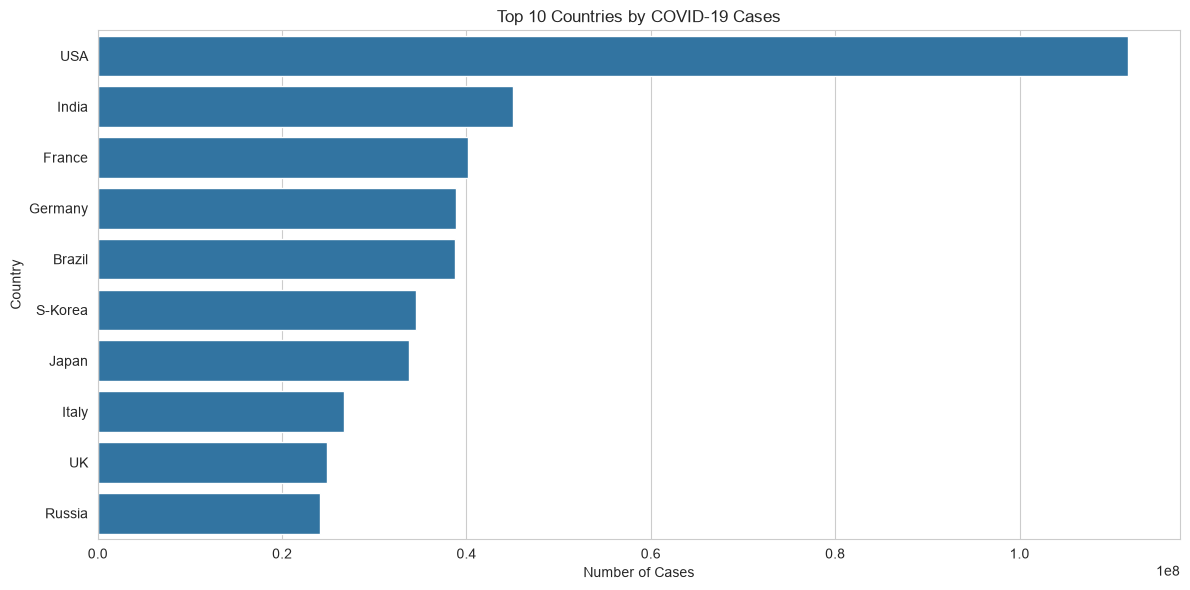

In [8]:
top_cases = country_data.sort_values(
    "Cases",
    ascending=False
).head(10)

display(
    top_cases[
        ["country", "continent", "Cases", "Recovered", "Deaths"]
    ]
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_cases,
    x="Cases",
    y="country"
)

plt.title("Top 10 Countries by COVID-19 Cases")
plt.xlabel("Number of Cases")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

8 — Top 10 Countries by Deaths

,country,continent,Cases,Deaths,Death Rate (%)
219,USA,North-America,111820082,1219487.0,1.090580
223,Brazil,South-America,38743918,711380.0,1.836108
220,India,Asia,45035393,533570.0,1.184779
228,Russia,Europe,24124215,402756.0,1.669509
235,Mexico,North-America,7702809,334958.0,4.348518
227,UK,Europe,24910387,232112.0,0.931788
181,Peru,South-America,4572667,222161.0,4.858456
226,Italy,Europe,26723249,196487.0,0.735266
222,Germany,Europe,38828995,183027.0,0.471367
221,France,Europe,40138560,167642.0,0.417658


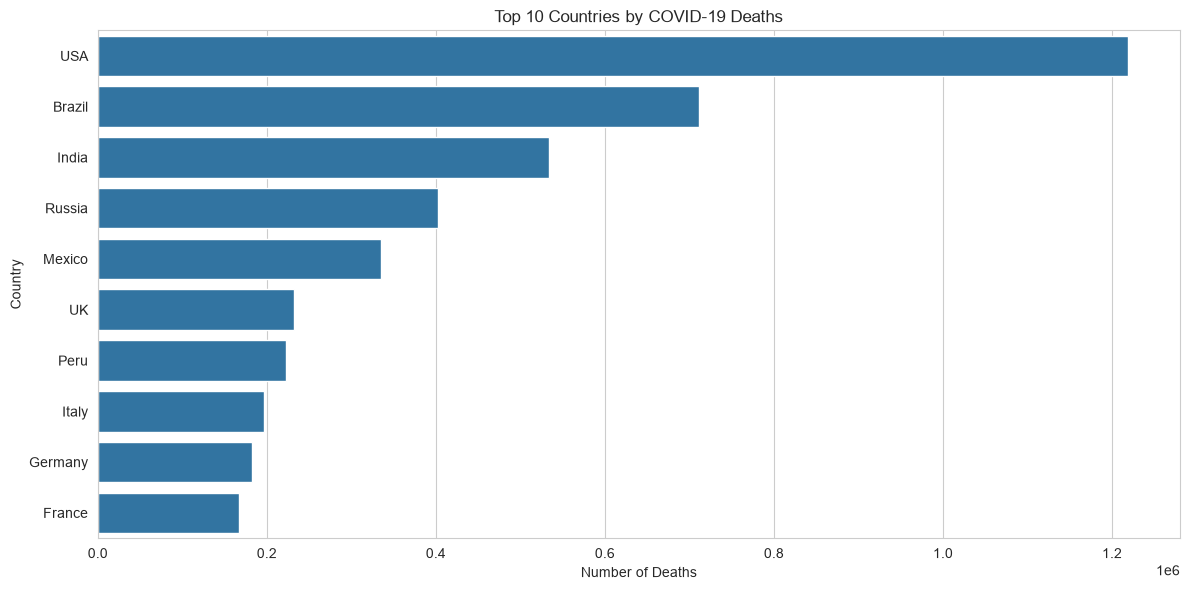

In [10]:
top_deaths = country_data.sort_values(
    "Deaths",
    ascending=False
).head(10)

display(
    top_deaths[
        ["country", "continent", "Cases", "Deaths", "Death Rate (%)"]
    ]
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_deaths,
    x="Deaths",
    y="country"
)

plt.title("Top 10 Countries by COVID-19 Deaths")
plt.xlabel("Number of Deaths")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

9 — Continent-wise Analysis

In [11]:
continent_summary = continent_data.groupby(
    "continent"
).agg(
    Countries=("country", "nunique"),
    Cases=("Cases", "sum"),
    Recovered=("Recovered", "sum"),
    Deaths=("Deaths", "sum"),
    Tests=("Tests", "sum")
).reset_index()

continent_summary["Recovery Rate (%)"] = np.where(
    continent_summary["Cases"] > 0,
    continent_summary["Recovered"] /
    continent_summary["Cases"] * 100,
    0
)

continent_summary["Death Rate (%)"] = np.where(
    continent_summary["Cases"] > 0,
    continent_summary["Deaths"] /
    continent_summary["Cases"] * 100,
    0
)

continent_summary = continent_summary.sort_values(
    "Cases",
    ascending=False
)

display(continent_summary)

,continent,Countries,Cases,Recovered,Deaths,Tests,Recovery Rate (%),Death Rate (%)
2,Europe,48,253406198,235797174.0,2101824.0,2.848047e+09,93.051068,0.829429
1,Asia,50,221500265,108524029.0,1553662.0,2.404652e+09,48.994988,0.701427
3,North-America,39,131889132,126483239.0,1695941.0,1.325710e+09,95.901184,1.285884
5,South-America,14,70200879,65935495.0,1367332.0,2.453954e+08,93.924030,1.947742
4,Oceania,20,14895771,14615509.0,33015.0,9.166819e+07,98.118513,0.221640
0,Africa,58,12860924,9211514.0,258892.0,1.110326e+08,71.624045,2.013012


10 — Cases by Continent Graph

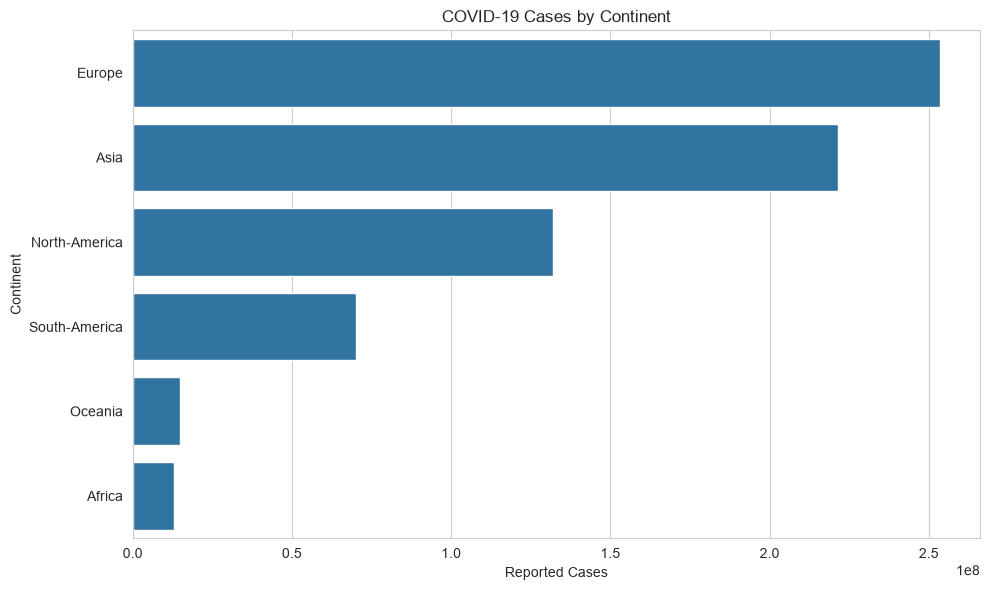

In [18]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=continent_summary,
    x="Cases",
    y="continent"
)

plt.title("COVID-19 Cases by Continent")
plt.xlabel("Reported Cases")
plt.ylabel("Continent")

plt.tight_layout()
plt.show()

11 — Cases, Recoveries and Deaths

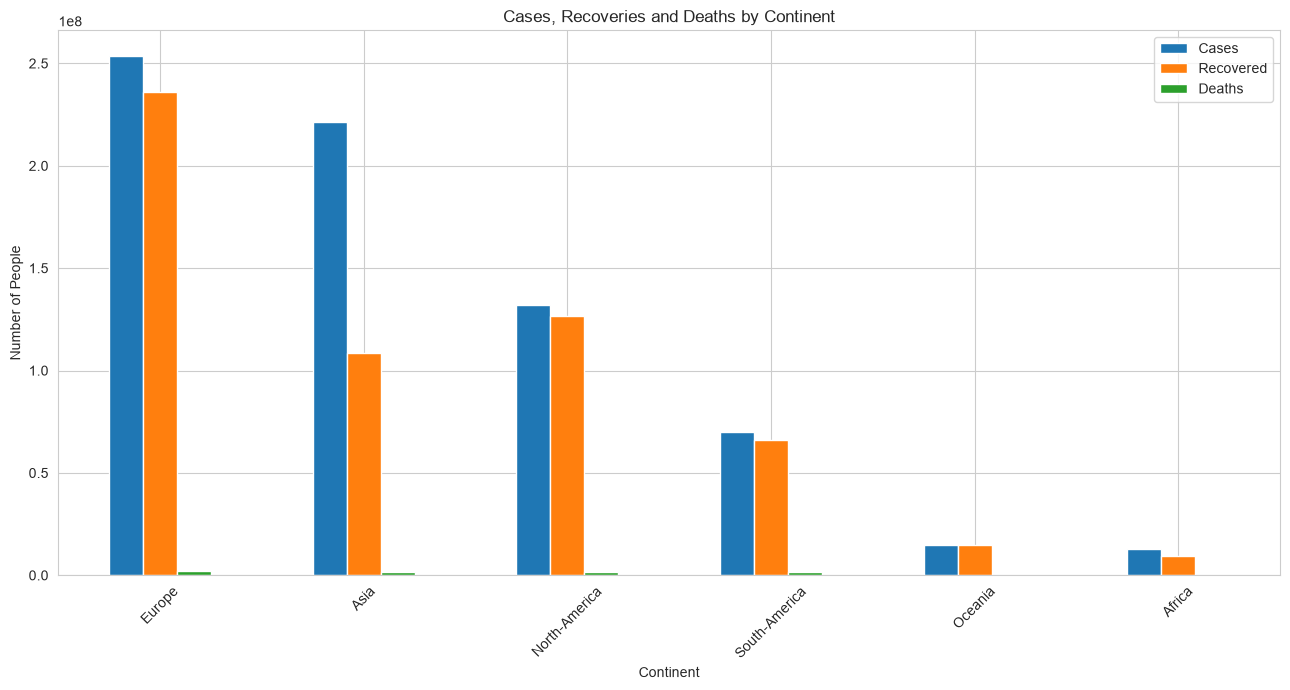

In [13]:
plot_data = continent_summary.set_index(
    "continent"
)[["Cases", "Recovered", "Deaths"]]

plot_data.plot(
    kind="bar",
    figsize=(13, 7)
)

plt.title("Cases, Recoveries and Deaths by Continent")
plt.xlabel("Continent")
plt.ylabel("Number of People")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

12 — Recovery Rate vs Death Rate

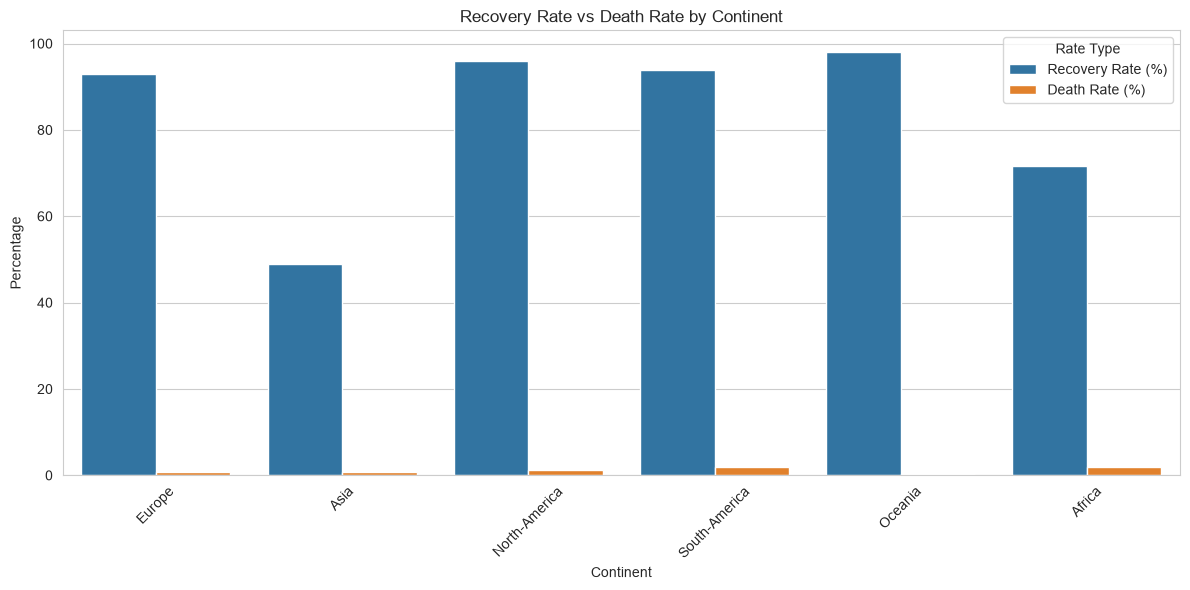

In [14]:
rate_data = continent_summary.melt(
    id_vars="continent",
    value_vars=[
        "Recovery Rate (%)",
        "Death Rate (%)"
    ],
    var_name="Rate Type",
    value_name="Rate (%)"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=rate_data,
    x="continent",
    y="Rate (%)",
    hue="Rate Type"
)

plt.title("Recovery Rate vs Death Rate by Continent")
plt.xlabel("Continent")
plt.ylabel("Percentage")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

13 — Cases per 100K Population

,country,population,Cases,Cases per 100K Population
152,Brunei,445431.0,343719,77165.486910
87,San-Marino,34085.0,26185,76822.649259
81,Faeroe-Islands,49233.0,34658,70395.872687
224,S-Korea,51329899.0,34571873,67352.310590
172,Austria,9066710.0,6081287,67072.697814
11,Niue,1622.0,1059,65289.765721
201,Slovenia,2078034.0,1356546,65280.260092
73,Andorra,77463.0,48015,61984.431277
161,Martinique,374087.0,230354,61577.654396
221,France,65584518.0,40138560,61201.273142


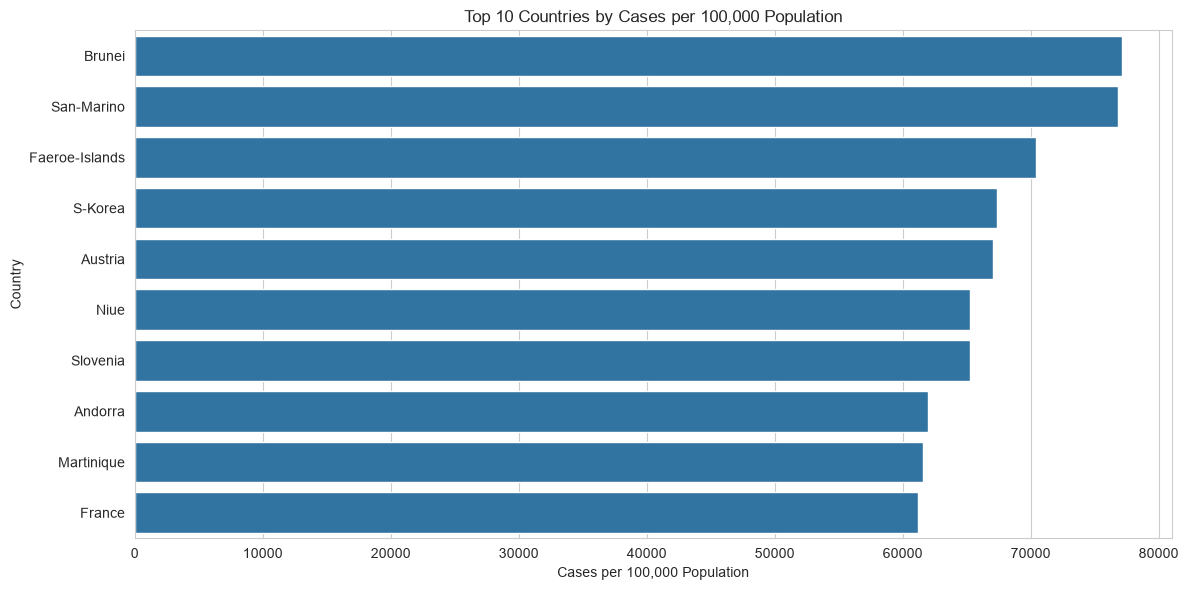

In [15]:
top_rate = country_data.dropna(
    subset=["Cases per 100K Population"]
).sort_values(
    "Cases per 100K Population",
    ascending=False
).head(10)

display(
    top_rate[
        [
            "country",
            "population",
            "Cases",
            "Cases per 100K Population"
        ]
    ]
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_rate,
    x="Cases per 100K Population",
    y="country"
)

plt.title("Top 10 Countries by Cases per 100,000 Population")
plt.xlabel("Cases per 100,000 Population")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

14 — Correlation Heatmap

,Cases,Recovered,Deaths,Tests,population
Cases,1.000000,0.920006,0.886343,0.838564,0.367741
Recovered,0.920006,1.000000,0.829282,0.713163,0.169546
Deaths,0.886343,0.829282,1.000000,0.802319,0.405260
Tests,0.838564,0.713163,0.802319,1.000000,0.542115
population,0.367741,0.169546,0.405260,0.542115,1.000000


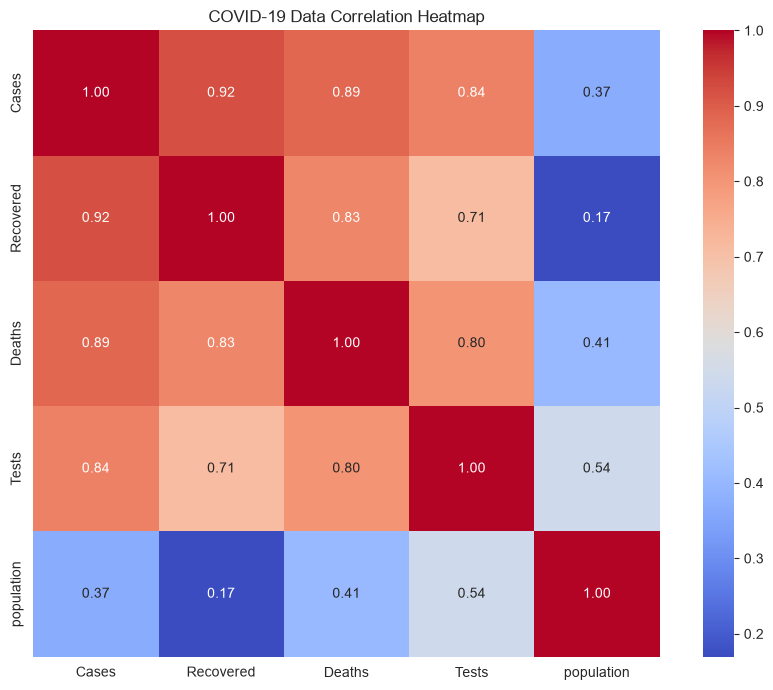

In [16]:
corr_cols = [
    "Cases",
    "Recovered",
    "Deaths",
    "Tests",
    "population"
]

correlation = country_data[corr_cols].corr()

display(correlation)

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)

plt.title("COVID-19 Data Correlation Heatmap")

plt.tight_layout()
plt.show()

15 — Interactive Plotly Chart

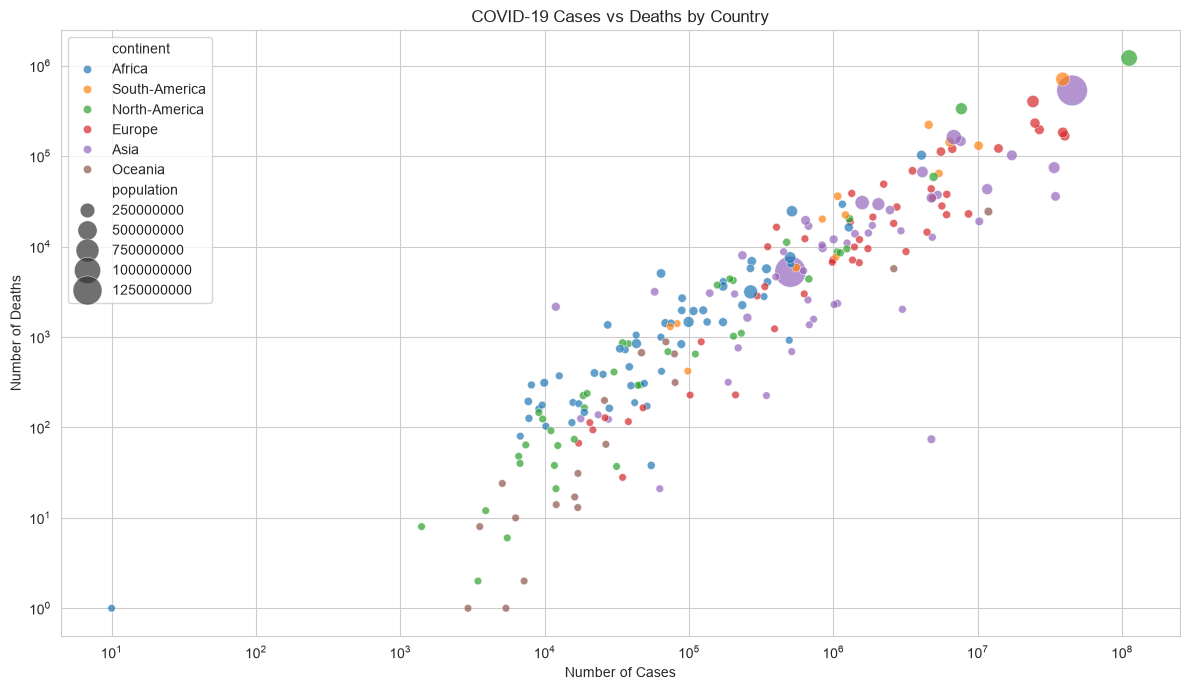

In [17]:
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=country_data,
    x="Cases",
    y="Deaths",
    hue="continent",
    size="population",
    sizes=(30, 500),
    alpha=0.7
)

plt.title("COVID-19 Cases vs Deaths by Country")
plt.xlabel("Number of Cases")
plt.ylabel("Number of Deaths")

plt.xscale("log")
plt.yscale("log")

plt.tight_layout()
plt.show()

16 — Key Findings

In [21]:
highest_cases_country = country_data.loc[
    country_data["Cases"].idxmax(),
    "country"
]

highest_cases_value = country_data["Cases"].max()

highest_deaths_country = country_data.loc[
    country_data["Deaths"].idxmax(),
    "country"
]

highest_deaths_value = country_data["Deaths"].max()

highest_cases_continent = continent_summary.loc[
    continent_summary["Cases"].idxmax(),
    "continent"
]

print("KEY FINDINGS")
print("=" * 50)

print(
    f"1. Country with highest reported cases: "
    f"{highest_cases_country} "
    f"({highest_cases_value:,.0f})"
)

print(
    f"2. Country with highest reported deaths: "
    f"{highest_deaths_country} "
    f"({highest_deaths_value:,.0f})"
)

print(
    f"3. Continent with highest reported cases: "
    f"{highest_cases_continent}"
)

print(
    f"4. Overall recovery rate: "
    f"{overall_recovery_rate:.2f}%"
)

print(
    f"5. Overall death rate: "
    f"{overall_death_rate:.2f}%"
)

print(
    f"6. Dataset date: "
    f"{data['day'].min().date()}"
)

KEY FINDINGS
1. Country with highest reported cases: USA (111,820,082)
2. Country with highest reported deaths: USA (1,219,487)
3. Continent with highest reported cases: Europe
4. Overall recovery rate: 79.54%
5. Overall death rate: 0.99%
6. Dataset date: 2024-06-30


17-conclusion

# Conclusion

The COVID-19 dataset was analyzed using Python libraries such as Pandas, NumPy, Matplotlib and Seaborn.

The analysis examined:

- COVID-19 cases
- Recoveries
- Deaths
- Tests
- Country-wise statistics
- Continent-wise statistics
- Recovery rate
- Death rate
- Cases per 100,000 population
- Correlation between different variables

The visualizations make it easier to compare the impact of COVID-19 across different countries and continents.

## Dataset Limitation

This particular CSV contains data for only one date. Therefore, it cannot be used to accurately analyze COVID-19 trends over time or the effect of government interventions over multiple dates. 